<a href="https://colab.research.google.com/github/dmora20/EconomiaUAQ/blob/main/fraude_tarjetas_credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deteccion de Fraudes en Tarjetas de Credito
**Terminal de Economia — LMA, UAQ**

## Parte 1 — Importar librerias

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline

COLOR_NORMAL = "#4C9BE8"
COLOR_FRAUDE = "#E85C5C"
PALETTE      = [COLOR_NORMAL, COLOR_FRAUDE]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## Parte 2 — Cargar los datos


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
df = pd.read_csv("/content/drive/MyDrive/analisisfraudeTdC/card_transdata.csv")

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print()
df.head()

Filas:    1,000,000
Columnas: 8



,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


## Parte 3 — Exploracion inicial

| Variable | Descripcion |
|---|---|
| `distance_from_home` | Distancia (km) entre el comercio y el domicilio del titular |
| `distance_from_last_transaction` | Distancia (km) respecto a la transaccion anterior |
| `ratio_to_median_purchase_price` | Que tan grande es esta compra respecto al gasto habitual del titular (1.0 = igual al promedio, 3.0 = tres veces mas grande) |
| `repeat_retailer` | Si el comercio ya habia sido usado antes (1 = si, 0 = no) |
| `used_chip` | Si se uso el chip de la tarjeta (1 = si, 0 = no) |
| `used_pin_number` | Si se uso el PIN (1 = si, 0 = no) |
| `online_order` | Si la compra fue en linea (1 = si, 0 = no) |
| `fraud` | Variable objetivo: 1 = fraude, 0 = normal |

In [23]:
# Tipos de datos y valores faltantes
print("Tipos de datos:")
print(df.dtypes)
print()
print(f"Valores faltantes en todo el dataset: {df.isnull().sum().sum()}")

Tipos de datos:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

Valores faltantes en todo el dataset: 0


In [24]:
# Estadisticas generales
df.describe().round(2)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.0,1000000.00,1000000.00
mean,26.63,5.04,1.82,0.88,0.35,0.1,0.65,0.09
std,65.39,25.84,2.80,0.32,0.48,0.3,0.48,0.28
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00
25%,3.88,0.30,0.48,1.00,0.00,0.0,0.00,0.00
50%,9.97,1.00,1.00,1.00,0.00,0.0,1.00,0.00
75%,25.74,3.36,2.10,1.00,1.00,0.0,1.00,0.00
max,10632.72,11851.10,267.80,1.00,1.00,1.0,1.00,1.00


In [25]:
# Cuantos fraudes hay en total?
conteo = df["fraud"].value_counts()
pct    = df["fraud"].mean() * 100

print(f"Transacciones normales: {conteo[0]:>10,}  ({100-pct:.2f}%)")
print(f"Transacciones fraude:   {conteo[1]:>10,}  ({pct:.2f}%)")
print(f"Total:                  {len(df):>10,}")

Transacciones normales:    912,597  (91.26%)
Transacciones fraude:       87,403  (8.74%)
Total:                   1,000,000


## Parte 4 — Limpieza de datos


In [43]:
# Copia del original
df_clean = df.copy()

# Etiqueta para graficas
df_clean["tipo"] = df_clean["fraud"].map({0: "Normal", 1: "Fraude"})

# Ver si hay duplicados
antes = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Filas antes: {antes:,} | Despues: {len(df_clean):,} | Duplicados: {antes - len(df_clean):,}")
print("Datos listos")

Filas antes: 1,000,000 | Despues: 1,000,000 | Duplicados: 0
Datos listos


## Parte 5 — Gráficas

---

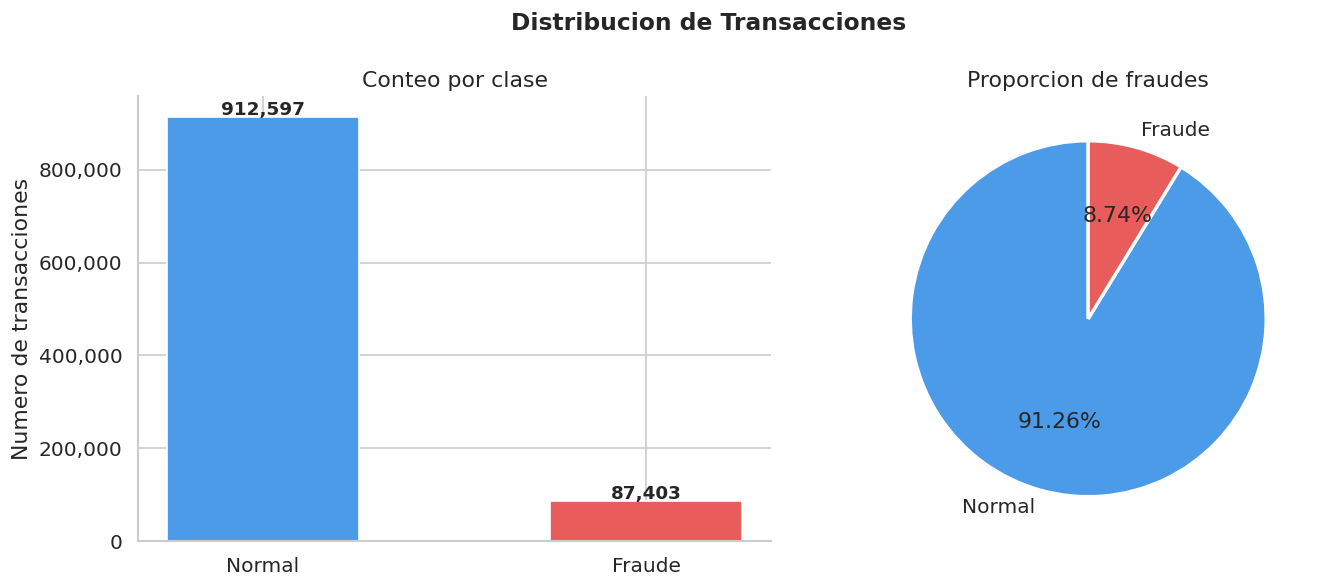

In [27]:
# Grafica 1: Distribucion general

conteo = df_clean["tipo"].value_counts().reindex(["Normal", "Fraude"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribucion de Transacciones", fontsize=14, fontweight="bold")

bars = axes[0].bar(conteo.index, conteo.values,
                   color=PALETTE, edgecolor="white", width=0.5)
for bar, v in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5000,
                 f"{v:,}", ha="center", fontweight="bold", fontsize=11)
axes[0].set_ylabel("Numero de transacciones")
axes[0].set_title("Conteo por clase")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
axes[0].spines[["top","right"]].set_visible(False)

axes[1].pie(conteo.values, labels=conteo.index, colors=PALETTE,
            autopct="%1.2f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proporcion de fraudes")

plt.tight_layout()
plt.savefig("grafica_distribucion.png", bbox_inches="tight", dpi=150)
plt.show()

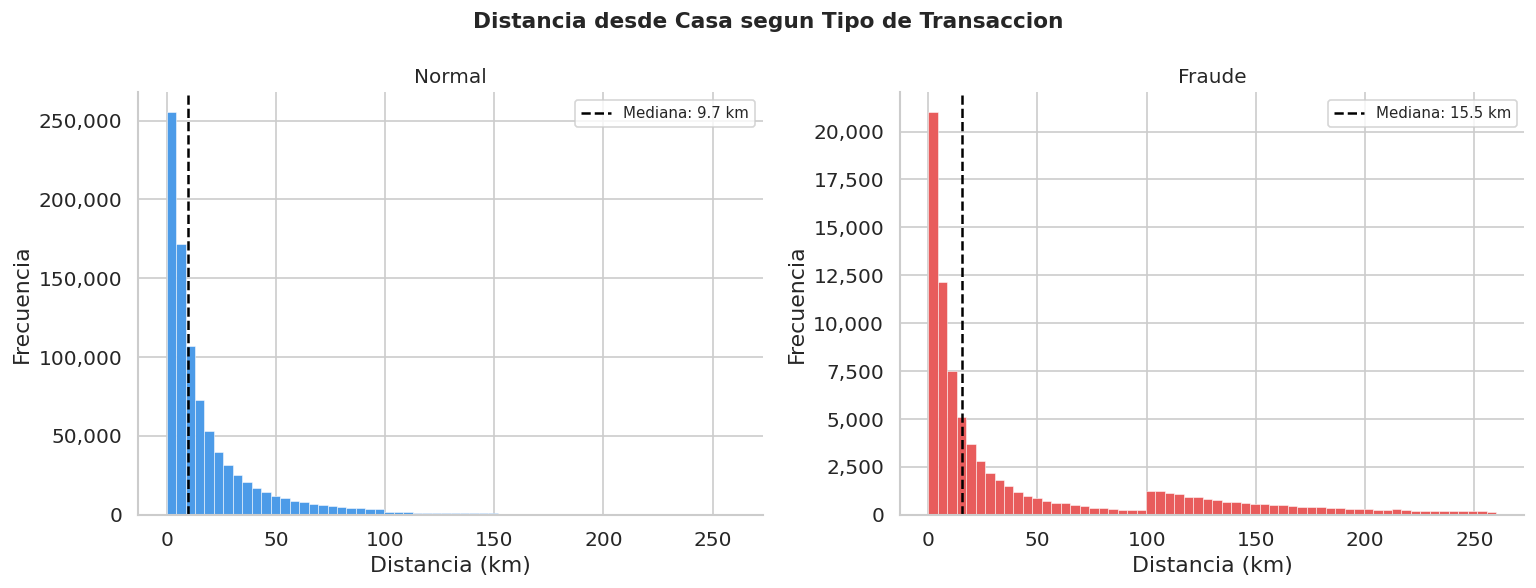

Mediana distancia — Normal: 9.7 km  |  Fraude: 15.5 km
Los fraudes ocurren en promedio 1.6x mas lejos del domicilio del titular.


In [28]:
# Grafica 2: Distancia desde casa segun tipo
# Las transacciones fraudulentas ocurren mas lejos del domicilio del titular?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distancia desde Casa segun Tipo de Transaccion", fontsize=13, fontweight="bold")

# Recortamos al percentil 99 para que no se sesgue la gráfica
lim = df_clean["distance_from_home"].quantile(0.99)

for ax, nombre, color in zip(axes, ["Normal", "Fraude"], PALETTE):
    datos   = df_clean[df_clean["tipo"]==nombre]["distance_from_home"]
    mediana = datos.median()
    ax.hist(datos[datos <= lim], bins=60, color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(mediana, color="black", linestyle="--", linewidth=1.5,
               label=f"Mediana: {mediana:.1f} km")
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("Distancia (km)")
    ax.set_ylabel("Frecuencia")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafica_distancia.png", bbox_inches="tight", dpi=150)
plt.show()

med_n = df_clean[df_clean["tipo"]=="Normal"]["distance_from_home"].median()
med_f = df_clean[df_clean["tipo"]=="Fraude"]["distance_from_home"].median()
print(f"Mediana distancia — Normal: {med_n:.1f} km  |  Fraude: {med_f:.1f} km")
print(f"Los fraudes ocurren en promedio {med_f/med_n:.1f}x mas lejos del domicilio del titular.")

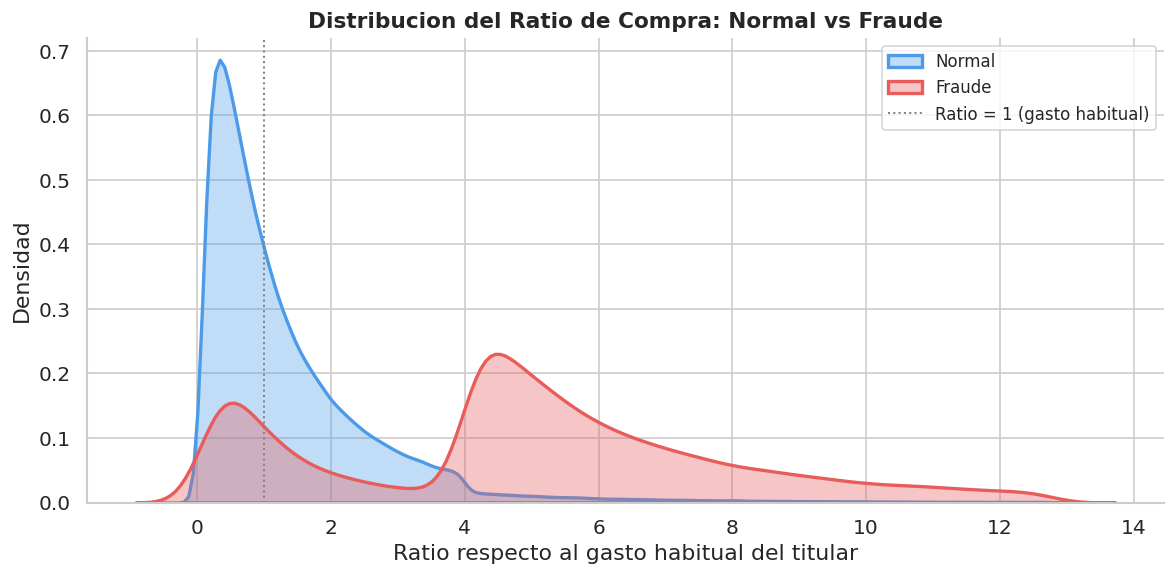

Mediana ratio — Normal: 0.91  |  Fraude: 5.07
En fraudes, el monto tipico es mas de 5 veces el gasto habitual del titular.


In [29]:
# Grafica 3: Ratio respecto al gasto habitual
# Un ratio de 5 significa que esta compra es 5 veces mas grande de lo normal para ese cliente.

fig, ax = plt.subplots(figsize=(10, 5))

lim_r = df_clean["ratio_to_median_purchase_price"].quantile(0.99)

for nombre, color in zip(["Normal", "Fraude"], PALETTE):
    datos = df_clean[df_clean["tipo"]==nombre]["ratio_to_median_purchase_price"]
    sns.kdeplot(datos[datos <= lim_r], ax=ax, label=nombre, color=color,
                fill=True, alpha=0.35, linewidth=2)

ax.set_title("Distribucion del Ratio de Compra: Normal vs Fraude",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Ratio respecto al gasto habitual del titular")
ax.set_ylabel("Densidad")
ax.axvline(1, color="gray", linestyle=":", linewidth=1.2, label="Ratio = 1 (gasto habitual)")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafica_ratio.png", bbox_inches="tight", dpi=150)
plt.show()

med_rn = df_clean[df_clean["tipo"]=="Normal"]["ratio_to_median_purchase_price"].median()
med_rf = df_clean[df_clean["tipo"]=="Fraude"]["ratio_to_median_purchase_price"].median()
print(f"Mediana ratio — Normal: {med_rn:.2f}  |  Fraude: {med_rf:.2f}")
print("En fraudes, el monto tipico es mas de 5 veces el gasto habitual del titular.")

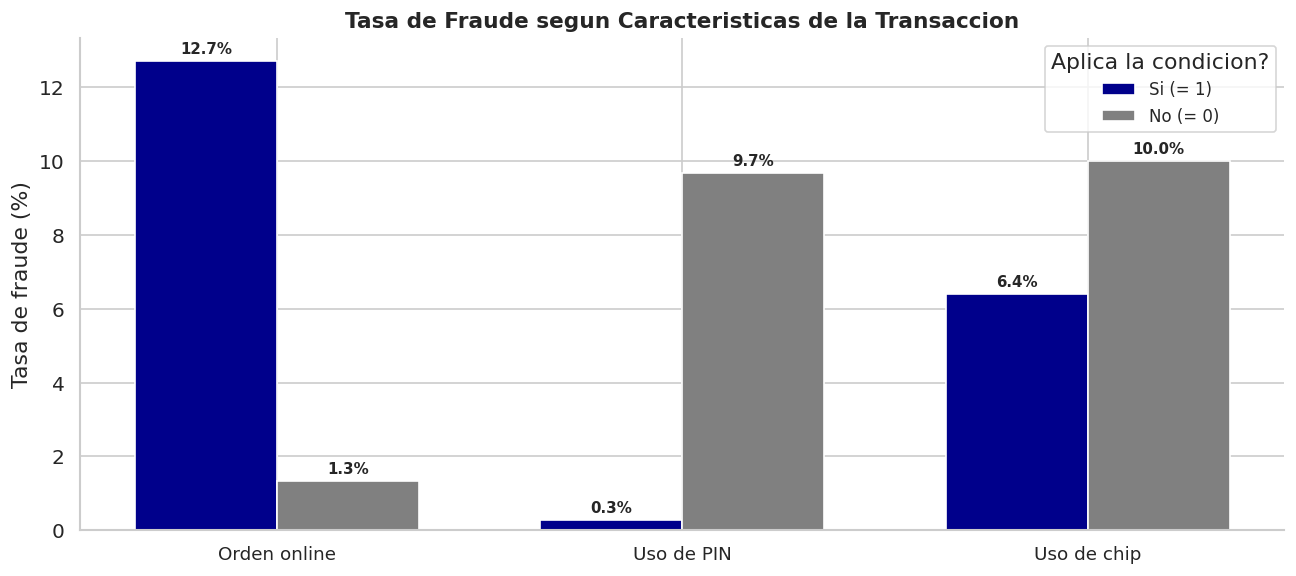

Cuando se usa PIN la tasa de fraude cae de 9.7% a solo 0.3%.
Las compras online tienen una tasa de fraude casi 10 veces mayor que las presenciales.


In [42]:
# Grafica 4: Tasa de fraude segun metodo de pago
# Que tan frecuente es el fraude dependiendo de si se uso chip, PIN o si fue online?

vars_binarias = {
    "online_order":    "Orden online",
    "used_pin_number": "Uso de PIN",
    "used_chip":       "Uso de chip",
}

tasas_si, tasas_no, etiquetas = [], [], []

for col, label in vars_binarias.items():
    tasas_si.append(df_clean[df_clean[col]==1]["fraud"].mean() * 100)
    tasas_no.append(df_clean[df_clean[col]==0]["fraud"].mean() * 100)
    etiquetas.append(label)

x     = np.arange(len(etiquetas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - ancho/2, tasas_si, ancho, label="Si (= 1)",
               color="darkblue", edgecolor="white")
bars2 = ax.bar(x + ancho/2, tasas_no, ancho, label="No (= 0)",
               color="gray", edgecolor="white")

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
            f"{h:.1f}%", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylabel("Tasa de fraude (%)")
ax.set_title("Tasa de Fraude segun Caracteristicas de la Transaccion",
             fontsize=13, fontweight="bold")
ax.legend(title="Aplica la condicion?", fontsize=10)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafica_metodos.png", bbox_inches="tight", dpi=150)
plt.show()

print("Cuando se usa PIN la tasa de fraude cae de 9.7% a solo 0.3%.")
print("Las compras online tienen una tasa de fraude casi 10 veces mayor que las presenciales.")

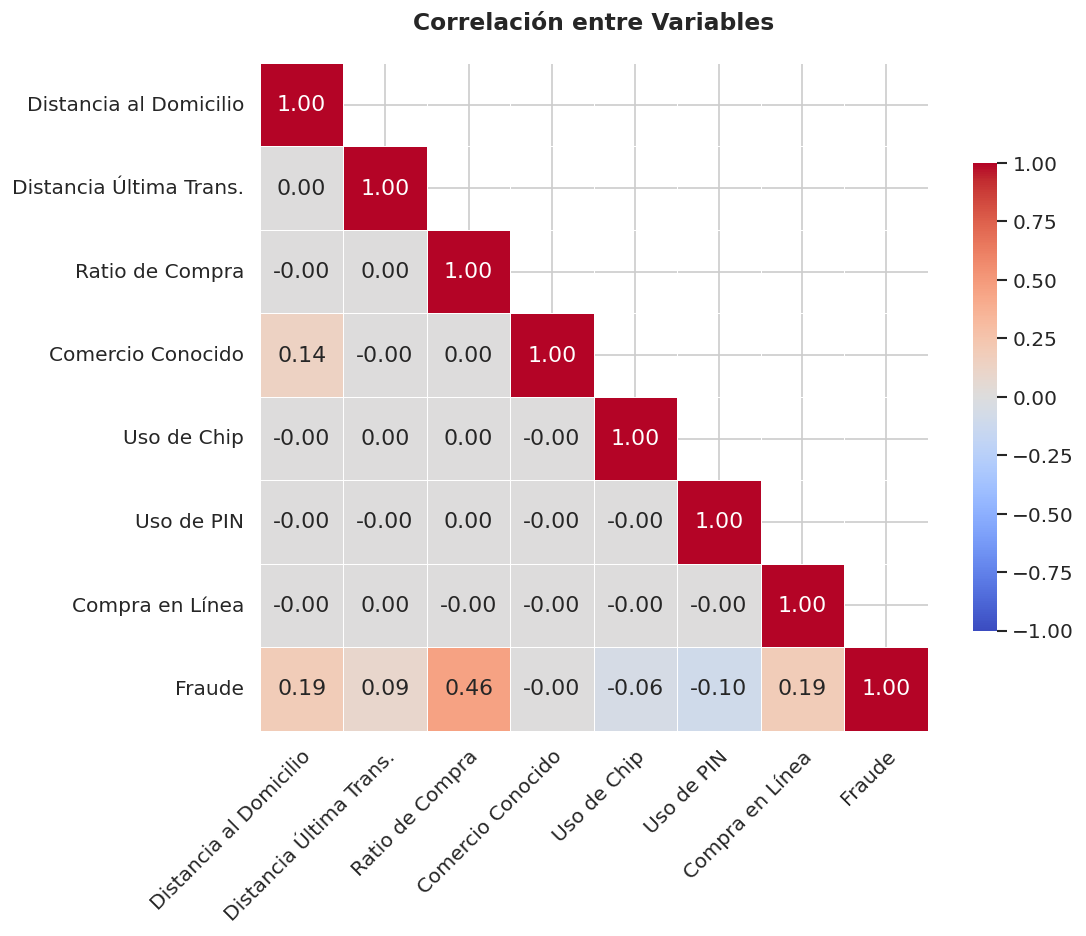

Correlación de cada variable con 'Fraude':
Ratio de Compra            0.46
Distancia al Domicilio     0.19
Compra en Línea            0.19
Distancia Última Trans.    0.09
Comercio Conocido         -0.00
Uso de Chip               -0.06
Uso de PIN                -0.10
Name: Fraude, dtype: float64


In [31]:
# Grafica 5: Mapa de correlaciones
corr = df_clean.drop(columns=["tipo"]).corr().round(2)

# Hacemos que 'fraud' quede al final
cols_orden = [c for c in corr.columns if c != "fraud"] + ["fraud"]
corr = corr[cols_orden].loc[cols_orden]

# Cambiar nombre a las variables
nombres_limpios = {
    "distance_from_home": "Distancia al Domicilio",
    "distance_from_last_transaction": "Distancia Última Trans.",
    "ratio_to_median_purchase_price": "Ratio de Compra",
    "repeat_retailer": "Comercio Conocido",
    "used_chip": "Uso de Chip",
    "used_pin_number": "Uso de PIN",
    "online_order": "Compra en Línea",
    "fraud": "Fraude"
}

corr = corr.rename(columns=nombres_limpios, index=nombres_limpios)

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, ax=ax, mask=mask,
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5,
            linecolor="white", square=True,
            cbar_kws={"shrink": 0.7})

ax.set_title("Correlación entre Variables", fontsize=14, fontweight="bold", pad=20)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("grafica_correlacion.png", bbox_inches="tight", dpi=150)
plt.show()

print("Correlación de cada variable con 'Fraude':")

corr_fraude = corr["Fraude"].drop("Fraude").sort_values(ascending=False)
print(corr_fraude)

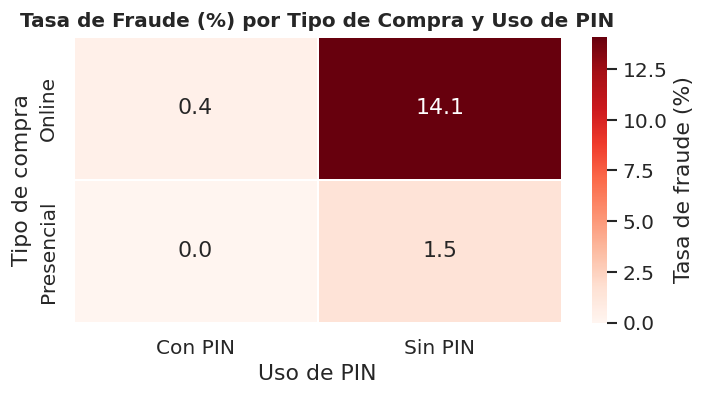

In [32]:
# Grafica 6: Tabla cruzada online vs PIN
# Tasa de fraude segun la combinacion de los dos factores mas relevantes.

tabla = pd.crosstab(
    df_clean["online_order"].map({0: "Presencial", 1: "Online"}),
    df_clean["used_pin_number"].map({0: "Sin PIN", 1: "Con PIN"}),
    values=df_clean["fraud"],
    aggfunc="mean"
).round(4) * 100

tabla.index.name   = "Tipo de compra"
tabla.columns.name = "Uso de PIN"

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(tabla, ax=ax, cmap="Reds", annot=True,
            fmt=".1f", linewidths=1, linecolor="white",
            cbar_kws={"label": "Tasa de fraude (%)"})
ax.set_title("Tasa de Fraude (%) por Tipo de Compra y Uso de PIN",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("grafica_crosstab.png", bbox_inches="tight", dpi=150)
plt.show()

## Parte 6 — Analisis de patrones por filtrado


In [33]:
# Definimos perfiles de riesgo basados.

perfiles = {
    "Online + sin PIN": (
        (df_clean["online_order"] == 1) & (df_clean["used_pin_number"] == 0)
    ),
    "Online + lejos de casa (>50 km)": (
        (df_clean["online_order"] == 1) & (df_clean["distance_from_home"] > 50)
    ),
    "Ratio alto (>5) + sin PIN": (
        (df_clean["ratio_to_median_purchase_price"] > 5) & (df_clean["used_pin_number"] == 0)
    ),
    "Ratio alto (>5) + online": (
        (df_clean["ratio_to_median_purchase_price"] > 5) & (df_clean["online_order"] == 1)
    ),
    "Ratio alto + online + sin PIN": (
        (df_clean["ratio_to_median_purchase_price"] > 5) &
        (df_clean["online_order"] == 1) &
        (df_clean["used_pin_number"] == 0)
    ),
}

resultados = []
for nombre, mask in perfiles.items():
    sub = df_clean[mask]
    resultados.append({
        "Perfil de riesgo": nombre,
        "Transacciones": len(sub),
        "Fraudes": int(sub["fraud"].sum()),
        "Tasa de fraude": f"{sub['fraud'].mean()*100:.1f}%",
    })

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

               Perfil de riesgo  Transacciones  Fraudes Tasa de fraude
               Online + sin PIN         585143    82439          14.1%
Online + lejos de casa (>50 km)          81215    25280          31.1%
      Ratio alto (>5) + sin PIN          63940    44618          69.8%
       Ratio alto (>5) + online          46220    41689          90.2%
  Ratio alto + online + sin PIN          41502    41502         100.0%


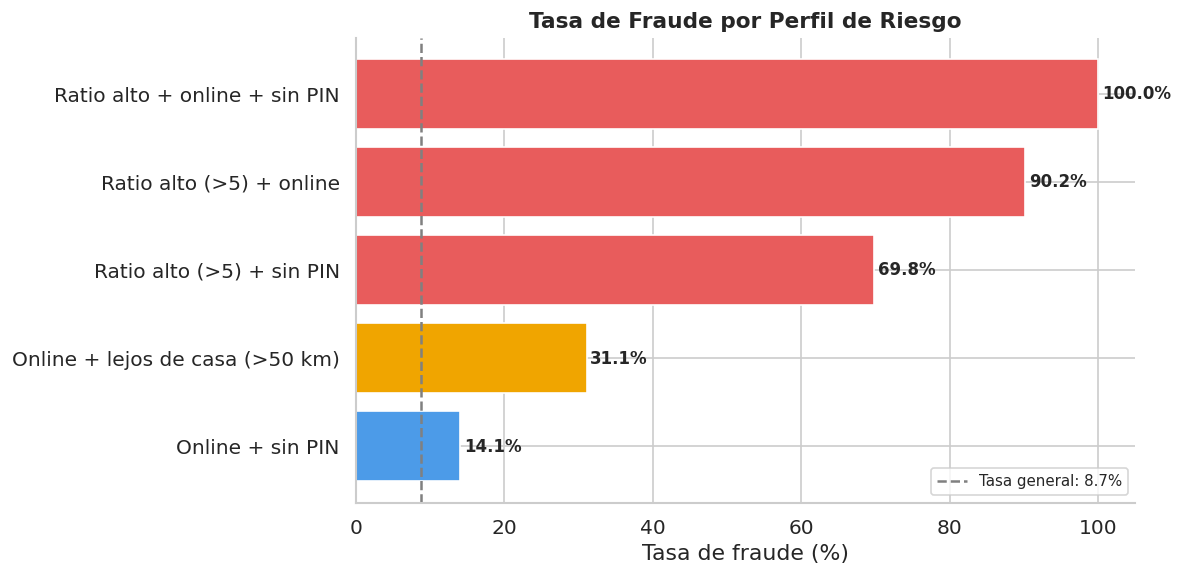

El perfil mas riesgoso tiene una tasa de fraude de casi 10 veces la tasa general (8.7%).


In [34]:
# Grafica 7: Tasa de fraude por perfil de riesgo

df_grafica = pd.DataFrame(resultados).copy()
df_grafica["Tasa_num"] = df_grafica["Tasa de fraude"].str.replace("%","").astype(float)
df_grafica = df_grafica.sort_values("Tasa_num")

colores_barra = [
    COLOR_FRAUDE if t > 50 else ("#F0A500" if t > 20 else COLOR_NORMAL)
    for t in df_grafica["Tasa_num"]
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_grafica["Perfil de riesgo"], df_grafica["Tasa_num"],
               color=colores_barra, edgecolor="white")

for bar, val in zip(bars, df_grafica["Tasa_num"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")

tasa_gral = df_clean["fraud"].mean() * 100
ax.axvline(tasa_gral, color="gray", linestyle="--", linewidth=1.5,
           label=f"Tasa general: {tasa_gral:.1f}%")
ax.set_xlabel("Tasa de fraude (%)")
ax.set_title("Tasa de Fraude por Perfil de Riesgo",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("grafica_perfiles.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"El perfil mas riesgoso tiene una tasa de fraude de casi 10 veces la tasa general ({tasa_gral:.1f}%).")

## Parte 7 — Conclusiones

In [35]:
tasa_gral   = df_clean["fraud"].mean() * 100
tasa_perfil = df_clean[
    (df_clean["ratio_to_median_purchase_price"] > 5) &
    (df_clean["online_order"] == 1) &
    (df_clean["used_pin_number"] == 0)
]["fraud"].mean() * 100

print("=" * 55)
print("       RESUMEN DE HALLAZGOS")
print("=" * 55)
print(f"  Dataset: 1,000,000 transacciones | Fraude: {tasa_gral:.2f}%")
print()
print("  PATRONES IDENTIFICADOS:")
print("  1. Compras online tienen ~10x mas fraude que presenciales.")
print("  2. Uso de PIN reduce el fraude de 9.7% a solo 0.3%.")
print("  3. Ratio > 5 indica monto inusual y se asocia a fraude.")
print("  4. Lejos del domicilio + online = 31% de fraude.")
print()
print("  PERFIL MAS RIESGOSO:")
print(f"  Ratio > 5 + Online + Sin PIN  ->  {tasa_perfil:.1f}% de fraude")
print()
print("  CONCLUSION:")
print("  Tres condiciones simples explican la mayoria del fraude:")
print("  compra online, monto inusual y sin PIN.")
print("  Un banco puede usar estos filtros directamente para")
print("  priorizar que transacciones revisar.")
print("=" * 55)

       RESUMEN DE HALLAZGOS
  Dataset: 1,000,000 transacciones | Fraude: 8.74%

  PATRONES IDENTIFICADOS:
  1. Compras online tienen ~10x mas fraude que presenciales.
  2. Uso de PIN reduce el fraude de 9.7% a solo 0.3%.
  3. Ratio > 5 indica monto inusual y se asocia a fraude.
  4. Lejos del domicilio + online = 31% de fraude.

  PERFIL MAS RIESGOSO:
  Ratio > 5 + Online + Sin PIN  ->  100.0% de fraude

  CONCLUSION:
  Tres condiciones simples explican la mayoria del fraude:
  compra online, monto inusual y sin PIN.
  Un banco puede usar estos filtros directamente para
  priorizar que transacciones revisar.
